## Import Libraries

In [ ]:
!pip install qiskit

!pip install qiskit-aer

!pip install tdqr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.4 MB/s eta 0:00:00


In [105]:
import numpy as np
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.circuit.library import RZZGate, IGate
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
import qiskit.circuit.classical as qiskit_classical
from qiskit.quantum_info import SparsePauliOp
from IPython.display import display
#from qiskit.opflow import I, Z, StateFn, PauliExpectation, CircuitSampler
#from qiskit import Aer, execute, transpile
from qiskit_aer.primitives import EstimatorV2 # as AerEstimator

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

## AER Pure SWAPNET

### Set SWAPNET

In [ ]:
class ising_class:
    def __init__(self, d, steps, t, J, h):
        self.d = d
        self.steps = steps
        self.t = t
        self.J = J
        self.h = h

    def get_trotterized_ising_circuit(self):
        
        """
        Returns a QuantumCircuit implementing a trotterized Ising evolution for d qubits.

        H = - J * sum(Z_i Z_{i+1}) - h * sum(X_i)
        U = exp(-i H t) 
        """
        t = self.t
        steps = self.steps
        d = self.d
        J = self.J
        h = self.h

        dt = t / steps
        qc = QuantumCircuit(d)

        from qiskit.circuit.library import RZZGate

        for _ in range(steps):
          # Even pairs: (0,1), (2,3), ...
          for i in range(0, d - 1, 2):
              qc.append(RZZGate(-2 * J * dt), [i, i + 1])
          # Odd pairs: (1,2), (3,4), ...
          for i in range(1, d - 1, 2):
              qc.append(RZZGate(-2 * J * dt), [i, i + 1])
          # Apply transverse field X terms (X_i)
          for i in range(d):
              qc.rx(-2 * h * dt, i)
        return qc

    def apply_ising_to_registers(self, qc):
        """
        Apply trotterized Ising circuit to registers q1, q2, q3 in a 4d-sized register circuit without packaging.
        """
        d = self.d
        ising = self.get_trotterized_ising_circuit()
        for reg in [1, 2, 3]:
          for gate, qargs, cargs in ising.data:
              mapped_qargs = [qc.qubits[reg * d + ising.qubits.index(q)] for q in qargs]
              qc.append(gate, mapped_qargs, cargs)
        return qc

    def get_trotterized_ising_statevector(self):
        """
        Returns the statevector from the trotterized Ising evolution of d qubits.
        """
        qc = self.get_trotterized_ising_circuit()
        qc.save_statevector()

        simulator = AerSimulator()
        result = simulator.run(transpile(qc, simulator)).result()
        return result.get_statevector()

def get_QPA_circuit(k, N, ising_circuit):
    #FUNCTION TO GET QPA CIRCUIT
    cr_q0 = ClassicalRegister(k,name='control')
    qr_all = QuantumRegister(4*k)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for i in range(k):
        qc.reset(i)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for i in range(k-1):
        qc.cx(0,1+i)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for i in range(k):
        qc.append(IGate(label='id_noisy'), [i])
        qc.cswap(0+i, i+k, i+2*k)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for i in range(k):
        qc.h(i) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1


      for i in range(k): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for i in range(k):
          qc.swap(i+2*k, i+3*k) #Swap q2 with q3
        if N!=1:
          qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc

def run_qc_and_return_state(qc):

    # Select Aer Simulator backend
    simulator = EstimatorV2()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state

def estimate_qc_and_return_distribution(qc,observables,estimator = EstimatorV2()):
    #RUN THE CIRCUIT AND MEASURE CLASSICALLY THE STATE IN REGISTER Q3, SHOULD RETURN A SEQUENCE OF BITS OF d DIMENSIONS FOR EACH SHOT, REPRESENTING THE FINAL STATE MEASURED
    pass_manager = generate_preset_pass_manager(3, EstimatorV2())
    isa_circuit = pass_manager.run(qc)
    qc_transpiled = transpile(isa_circuit)

    result = estimator.run([(qc_transpiled,observables,None)]).result()
    exp_val = result[0].data.evs
    print(result[0].data.stds)
    return exp_val
    # pub_result = result[0]
    # counts = pub_result.data.control.get_counts()
    # return counts
RZZGate(2).to_matrix()

array([[0.54030231-0.84147098j, 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.54030231+0.84147098j,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.54030231+0.84147098j, 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.54030231-0.84147098j]])

In [131]:
#Printing circuit
#  
t=1
J=1
h=1
steps = 5
k=3

ising = ising_class(k, steps, t, J, h)
epsilon = 1.0
N_qpa = 2
QPA = get_QPA_circuit(k, N_qpa, ising)


trotterized_state = ising.get_trotterized_ising_statevector()
display(trotterized_state.draw('latex'))
#CALCULATE THE PROJECTION OPERATOR FOR THE Q3 REGISTER -------------------
# Assuming trotterized_state is your Statevector for the q3 register
projector_q3 = SparsePauliOp.from_operator(trotterized_state.to_operator())


# Create an identity operator for the other registers
identity_op = SparsePauliOp(["I" * (k)])

# Tensor the identity with the projector
full_projector = projector_q3.tensor(identity_op).tensor(identity_op).tensor(identity_op)
# full_projector = identity_op.tensor(identity_op).tensor(identity_op).tensor(projector_q3)

# print(estimate_qc_and_return_distribution(QPA,[full_projector],estimator=estimator))


# TESTING THE ESTIMATOR ------------------------------------------------
state = trotterized_state  # type: Statevector

rho = state.to_operator()  # This is |psi><psi| as a matrix

projector_pauli = SparsePauliOp.from_operator(rho)

qc_ising = ising.get_trotterized_ising_circuit()
# print(transpile(qc_ising).draw())
# print(estimate_qc_and_return_distribution(qc_ising,[projector_pauli],estimator=estimator))



# # psi_purified = run_qc_and_return_state(QPA)
# print(transpile(QPA).draw())
# # display(psi_purified.draw('latex'))

# print(QPA.draw(fold=-1))
qc_transpiled = transpile(QPA,optimization_level=0)
print(qc_transpiled.draw(fold=-1))

# pass_manager = generate_preset_pass_manager(3, AerSimulator())
# isa_circuit = pass_manager.run(QPA)
# qc_transpiled = transpile(isa_circuit)
# print(isa_circuit.draw(fold=-1))


for inst, qargs, cargs in QPA.data:
    print(f"Gate name: {inst.name}, qubits: {qargs}")


/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_33032/784930723.py:48: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in ising.data:


<IPython.core.display.Latex object>

                         ┌───┐                                          ┌───┐                                                                                                                ┌───┐          ┌─┐      ┌──────────────────────────────────────── ┌────────            ┌───┐          ┌───┐      ┌───┐        ┌─┐                                                                           ───────┐ 
   q344_0: ────|0>───────┤ H ├─────────■──────────────────────■─────────┤ I ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ H ├──────────┤M├──────┤                                         ┤         ───────|0>─┤ H ├──■────■──┤ I ├────■─┤ H ├────────┤M├──────────────────────────────────────────────────────────────────────────        ├─
                         └───┘       ┌─┴─┐       ┌───┐        │         └───┘                                                                                                              │ └───┘

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_33032/235890807.py:59: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, cargs in QPA.data:


## RUN ESTIMATOR

In [132]:
t=1
J=1
h=1
steps = 5
k=3

ising = ising_class(k, steps, t, J, h)
trotterized_state = ising.get_trotterized_ising_statevector()
display(trotterized_state.draw('latex'))

fidelity_operator = SparsePauliOp.from_operator(trotterized_state.to_operator())

identity_op = SparsePauliOp(["I" * (k)])
full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(identity_op)


qc = ising.get_trotterized_ising_circuit()

# Get the full unitary matrix
unitary_matrix = Operator(qc).data
print(unitary_matrix)

<IPython.core.display.Latex object>

[[-4.50173224e-01+1.74357699e-01j -4.09811512e-01+4.79904992e-02j
  -1.36617327e-02-3.23130366e-02j -2.63769471e-01-7.09332509e-02j
  -4.09811512e-01+4.79904992e-02j -2.29703944e-01+9.71172698e-02j
  -2.63769471e-01-7.09332509e-02j  3.46553403e-01-3.06119115e-01j]
 [-3.96149779e-01-1.15385943e-01j  3.16634192e-01-1.38777878e-17j
  -2.15325062e-01+1.68050521e-01j  1.73472348e-18+3.66101218e-01j
  -2.23668114e-01+5.55111512e-17j  3.96149779e-01-1.15385943e-01j
   2.25514052e-17-4.75369766e-01j -2.15325062e-01-1.68050521e-01j]
 [ 1.36617327e-02-3.23130366e-02j -2.63769471e-01+7.09332509e-02j
  -4.50173224e-01-1.74357699e-01j  4.09811512e-01+4.79904992e-02j
  -2.63769471e-01+7.09332509e-02j -3.46553403e-01-3.06119115e-01j
   4.09811512e-01+4.79904992e-02j -2.29703944e-01-9.71172698e-02j]
 [-2.15325062e-01-1.68050521e-01j -1.73472348e-18+3.66101218e-01j
   3.96149779e-01-1.15385943e-01j  3.16634192e-01+1.38777878e-17j
  -2.25514052e-17-4.75369766e-01j -2.15325062e-01+1.68050521e-01j
  -2.23

In [138]:
#exact state calculation:
# Parameters
t = 1
J = 1.0
h = 1.0
k = 3  # number of qubits
dim = 2**k

# Pauli matrices
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

def kron_n(*ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

# Build Hamiltonian H = -J Σ Z_i Z_{i+1} - h Σ X_i
H = np.zeros((dim, dim), dtype=complex)

# Z_i Z_{i+1} terms
for q in range(k - 1):
    ops = [I] * k
    ops[q] = Z
    ops[q + 1] = Z
    H += -J * kron_n(*ops)

# X_i terms
for q in range(k):
    ops = [I] * k
    ops[q] = X
    H += -h * kron_n(*ops)
# Initial state |000>
psi0 = np.zeros(dim)
psi0[0] = 1.0

# Time evolution: U = exp(-iHt)
U = expm(-1j * H * t)
psi_final = U @ psi0

# Convert to Qiskit Statevector
exact_state = Statevector(psi_final)
# Display
display(exact_state.draw('latex'))

fidelity_operator = SparsePauliOp.from_operator(exact_state.to_operator())

identity_op = SparsePauliOp(["I" * (k)])
# full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(identity_op)
full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(identity_op)
state_fidelity(trotterized_state, exact_state)

<IPython.core.display.Latex object>

0.984935764034504

Lambda Loop:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_33032/784930723.py:48: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in ising.data:
Lambda Loop: 100%|██████████| 10/10 [00:51<00:00,  5.15s/it]


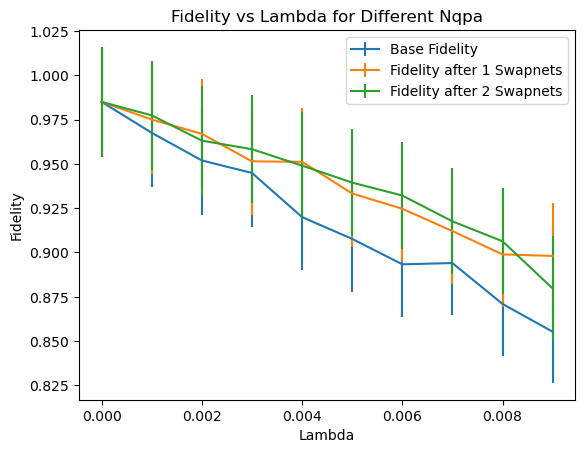

In [141]:
#DO THE PLOTTING -------------------------
import numpy as np
import matplotlib.pyplot as plt
import time  # Import time module for tracking execution time
from tqdm import tqdm
list_of_noise = [i * 0.001 for i in range(10)]
list_of_Nqpa = [0,1,2]
purified_fidelity = {i: [] for i in list_of_Nqpa}
theorical_fidelity=[]

shots = 1024
debug = False # Set to False to disable print statements



pass_manager = generate_preset_pass_manager(3, AerSimulator())

for noise in tqdm(list_of_noise, desc="Lambda Loop"):
    # Theoretical max fidelity
    # LAMBDA = ising.get_trotterized_ising_circuit
    # if d==2:#1/8 (-2 + \[Lambda]) (1 + \[Lambda]) (-4 + 3 \[Lambda])
    #     theorical_fidelity.append(1/8 * (-2 + LAMBDA) * (1 + LAMBDA) * (-4 + 3*LAMBDA))
    # elif d==3: #1/96 (-8 + 7 \[Lambda]) (-12 + 7 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/96 * (-8 + 7*LAMBDA) * (-12 + 7*(-1 + LAMBDA)*LAMBDA))
    # elif d==4:#1/128 (-16 + 15 \[Lambda]) (-8 + 5 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/128 * (-16 + 15*LAMBDA) * (-8 + 5*(-1 + LAMBDA)*LAMBDA))
    # else:#Just give 0 for now
    #     theorical_fidelity.append(0)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ['id_noisy','rx'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ['rzz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 3), ['cswap'])
    readout_error = ReadoutError([[1 - noise, noise], [noise, 1 - noise]])
    noise_model.add_all_qubit_readout_error(readout_error)
    estimator = EstimatorV2(options={
        'backend_options': {
            'noise_model': noise_model,
            'shots': shots
        }
    })


    for Nqpa in list_of_Nqpa:
        QPA = get_QPA_circuit(k, Nqpa, ising)
        # isa_circuit = pass_manager.run(QPA)
        qc_transpiled = transpile(QPA,optimization_level=0)
        result = estimator.run([(qc_transpiled,full_space_fidelity_operator,None)]).result()
        fidelity = result[0].data.evs
        # print(fidelity)
        purified_fidelity[Nqpa].append(fidelity)  


# print(purified_fidelity)
# Plot results
for Nqpa in list_of_Nqpa:
    fidelity = np.array(purified_fidelity[Nqpa])
    if Nqpa==0:
        label = 'Base Fidelity'
    else:
        label = f'Fidelity after {Nqpa} Swapnets'
    plt.errorbar(list_of_noise, purified_fidelity[Nqpa],
                 yerr=np.sqrt(fidelity/shots), label=label)

# plt.plot(list_of_lambda, theorical_fidelity, label='Theoretical Maximum Fidelity')

plt.xlabel('Lambda')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Lambda for Different Nqpa')
plt.legend()
plt.show()




In [ ]:
# Show available options for AerEstimator



{'default_precision': 0.0,
 'backend_options': {'noise_model': <NoiseModel on ['rx', 'measure']>,
  'shots': 1024},
 'run_options': {}}

In [130]:
qc = QuantumCircuit(2)
# qc.append(RZZGate(0.4),[0,1])
qc.rx(0.4,1)
# Get the unitary matrix of the gate
unitary = Operator(qc).data
print(unitary)

[[0.98006658+0.j         0.        +0.j         0.        -0.19866933j
  0.        +0.j        ]
 [0.        +0.j         0.98006658+0.j         0.        +0.j
  0.        -0.19866933j]
 [0.        -0.19866933j 0.        +0.j         0.98006658+0.j
  0.        +0.j        ]
 [0.        +0.j         0.        -0.19866933j 0.        +0.j
  0.98006658+0.j        ]]
